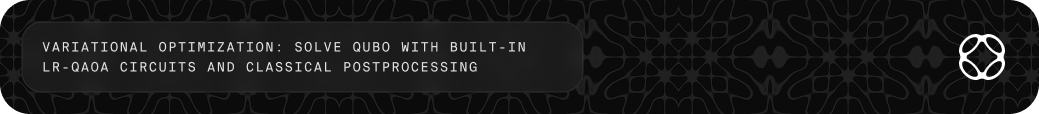

This notebook demonstrates the `haiqu.solve_qubo()` API that automatically handles quantum optimization end-to-end.

- For a 20-variable 6-regular Max-Cut problem (loaded from a deterministic reference graph), **the raw quantum results achieve a suboptimal solution**.
- With built-in post-processing, **haiqu.solve_qubo() achieves the optimal solution**—no additional quantum circuits required.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.solve_qubo()`

- **What does it do?** Provides a high-level interface for quantum optimization that automatically builds LR-QAOA circuits, runs them on quantum backends, applies post-processing, and calculates relevant metrics.
- **How do I use it?** Pass a QUBO problem, select a backend, configure circuit parameters (number of layers, shots), and optionally enable compression. The function returns comprehensive optimization results.
- **What are the options?**
  - `device_id` – choose backend (simulators or real hardware).
  - `p` – number of LR-QAOA layers.
  - `postprocess_iterations` – number of post-processing passes.
  - `compression` – enable circuit compression.
- **Which options do you recommend?** Start with `aer_simulator` for quick results. To improve solution quality:
  - `postprocess_iterations` (default 5) – increase for better results at the cost of runtime.
  - `p` (default 10) – adjust the number of LR-QAOA layers to improve solution quality.
  - `compression=True` – try enabling when running on hardware to reduce circuit depth and see how that improves the solution quality

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and create a 20-variable optimization problem. We'll demonstrate the value of built-in post-processing and CVaR analysis.

In [1]:
from haiqu.sdk import haiqu
from haiqu.sdk.optimization import QUBO
from qiskit_optimization.applications import Maxcut
import networkx as nx
import pandas as pd
import json

# Set pandas display options to show full column width
pd.set_option('display.max_colwidth', None)

haiqu.login()
haiqu.init("QUBO Solve Tutorial")

# Load Max-Cut graph from reference JSON file for deterministic results
graph_file = 'maxcut_graph_reference.json'

print(f"Loading reference graph from {graph_file}...")
with open(graph_file, 'r') as f:
    graph_data = json.load(f)

# Reconstruct the graph
G = nx.Graph()
G.add_nodes_from(graph_data['nodes'])
for edge in graph_data['edges']:
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])


print(f"Max-Cut Problem: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges ({graph_data['parameters']['degree_graph']}-regular graph)")

# Create QUBO
maxcut = Maxcut(G)
qp = maxcut.to_quadratic_program()
problem = QUBO.from_quadratic_program(qp)

Loading reference graph from maxcut_graph_reference.json...
Max-Cut Problem: 20 nodes, 60 edges (6-regular graph)


## Run benchmark scenarios

Run `haiqu.solve_qubo()` once and analyze results with and without post-processing.

In [2]:
# Run QAOA with shallow circuit
p = 1 # number of LR-QAOA layers
shots = 1_000
print(f"Running haiqu.solve_qubo() with p={p}, shots={shots}...\n")

result = haiqu.solve_qubo(
    problem=problem,
    device_id="aer_simulator",
    options={"method": "matrix_product_state"},
    p=p,
    shots=shots,
)

raw_best_cost = min(result.raw_costs.values())
processed_best_cost = min(result.processed_costs.values())

# Create scenarios
scenarios = [
    {
        "description": "Raw Quantum Results",
        "postprocess": False,
        "best_cost": raw_best_cost,
    },
    {
        "description": "With Postprocessing", 
        "postprocess": True,
        "best_cost": processed_best_cost,
    }
]

Running haiqu.solve_qubo() with p=1, shots=1000...



The `haiqu.solve_qubo()` function provides comprehensive optimization results. Summary of scenarios:

In [3]:
# baseline optimal solution: note that we always use the qiskit's little-endian convention for bitstrings where for example '01' means q1=0 and q0=1.
optimal_bitstring = '10001110010010101100'

# Calculate optimal cost
optimal_cost = problem.cost(optimal_bitstring)

print(f"True optimal cost (QUBO minimization): {optimal_cost:.2f}\n")

# Build results table
results_data = []

for scenario in scenarios:
    cost = scenario["best_cost"]

    gap = (cost - optimal_cost) / abs(optimal_cost)

    # Calculate normalized approximation ratio (for minimization problems)
    # ρ = 1 + (f(x) - f*) / |f*|
    normalized_approx_ratio = 1 + gap
    
    if gap < 1e-6:
        ratio_with_interpretation = f"{normalized_approx_ratio:.4f} (Optimal)"
    else:
        ratio_with_interpretation = f"{normalized_approx_ratio:.4f} ({gap*100:.1f}% worse than optimal)"
    
    # Determine business impact
    if scenario["description"] == "Raw Quantum Results":
        business_impact = "Demonstrates baseline quantum performance on the optimization problem"
    else:
        business_impact = "Achieves optimal solution at no extra quantum cost"

    results_data.append({
        "Scenario": scenario["description"],
        "Best Cost": f"{cost:.2f}",
        "Normalized Approximation Ratio": ratio_with_interpretation,
        "Business Impact": business_impact,
    })

pd.DataFrame(results_data)

True optimal cost (QUBO minimization): -97.84



,Scenario,Best Cost,Normalized Approximation Ratio,Business Impact
0,Raw Quantum Results,-84.72,1.1341 (13.4% worse than optimal),Demonstrates baseline quantum performance on the optimization problem
1,With Postprocessing,-97.84,1.0000 (Optimal),Achieves optimal solution at no extra quantum cost


> **💡 Good to Know:** The `haiqu.solve_qubo()` function automatically applies post-processing and provides advanced metrics such as CVar, providing both raw and refined results in a single call—no additional quantum runs required.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

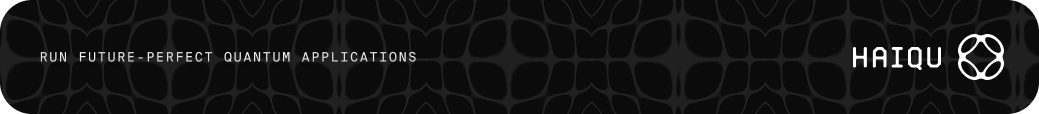